# Лабораторная работа 2. Обучение с учителем. Задача регрессии

## Задача регрессии

### Загрузка данных

In [870]:
import pandas as pd

In [871]:
data = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
data

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,67,466,2011,4,195000,1800,2,0,7750
1,55,314,2014,11,135000,1500,0,1,8550
2,55,369,2012,11,110000,1500,0,1,6550
3,51,122,2006,11,200000,1600,3,1,4100
4,45,628,2000,5,300000,2200,0,1,3490
...,...,...,...,...,...,...,...,...,...
27052,70,446,2016,10,88000,1800,4,0,11500
27053,39,287,2002,3,225000,1800,3,1,4400
27054,16,381,2015,11,89000,1500,0,1,7000
27055,44,72,2006,1,370000,2000,0,1,4000


### Первый шаг: выделение целевого признака и предикторов

In [872]:
y = data["Price(euro)"]
X = data.drop(["Price(euro)"], axis=1)

In [873]:
y

0         7750
1         8550
2         6550
3         4100
4         3490
         ...  
27052    11500
27053     4400
27054     7000
27055     4000
27056     4000
Name: Price(euro), Length: 27057, dtype: int64

In [874]:
X

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission
0,67,466,2011,4,195000,1800,2,0
1,55,314,2014,11,135000,1500,0,1
2,55,369,2012,11,110000,1500,0,1
3,51,122,2006,11,200000,1600,3,1
4,45,628,2000,5,300000,2200,0,1
...,...,...,...,...,...,...,...,...
27052,70,446,2016,10,88000,1800,4,0
27053,39,287,2002,3,225000,1800,3,1
27054,16,381,2015,11,89000,1500,0,1
27055,44,72,2006,1,370000,2000,0,1


In [875]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Разбиение на обучающую и тестовую выборки

In [876]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [877]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((21645, 8), (21645,), (5412, 8), (5412,))

### Линейная регрессия в sklearn (+ регуляризации и использование полиномов)

In [878]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from math import sqrt

In [879]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [880]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')
lr.coef_

MAE: 2277.2929637845864
MSE: 9574915.791853376
RMSE: 3094.33608256333
MAPE: 0.5539796868542677
R^2: 0.6691812642880409


array([   27.03284242,    74.57659924,  3278.0359976 ,  -170.14129109,
        -391.03481748,  1656.65171934,    62.39750306, -1060.70995859])

In [881]:
import matplotlib.pyplot as plt
import seaborn as sns

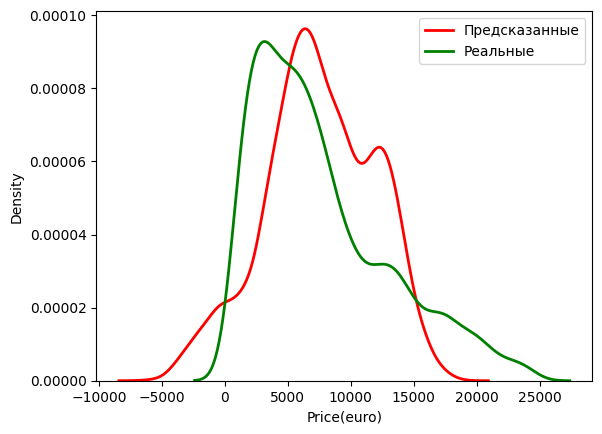

In [882]:
sns.kdeplot(y_pred, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [883]:
# L1
lasso = Lasso(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_lasso)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_lasso))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_lasso)}')
print(f'R^2: {r2_score(y_test, y_pred_lasso)}')
lasso.coef_

MAE: 2277.3252043974408
MSE: 9574957.38608641
RMSE: 3094.3428035830825
MAPE: 0.5539437470325773
R^2: 0.6691798271838528


array([   26.48637784,    74.30715568,  3277.40383511,  -169.69229899,
        -390.81501842,  1655.7654445 ,    61.64162816, -1060.83385229])

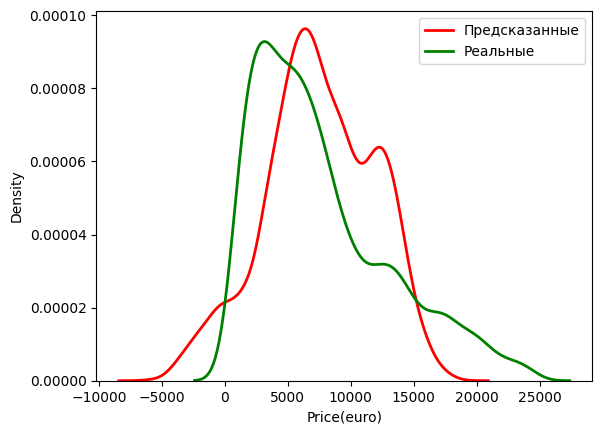

In [884]:
sns.kdeplot(y_pred_lasso, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [885]:
# L2
ridge = Ridge(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_ridge))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge)}')
print(f'R^2: {r2_score(y_test, y_pred_ridge)}')
ridge.coef_

MAE: 2277.2939373054323
MSE: 9574923.63418359
RMSE: 3094.337349770317
MAPE: 0.5539706069661834
R^2: 0.6691809933311132


array([   27.01880407,    74.59270365,  3277.90851348,  -170.13506106,
        -391.06485502,  1656.57583594,    62.35495948, -1060.75501248])

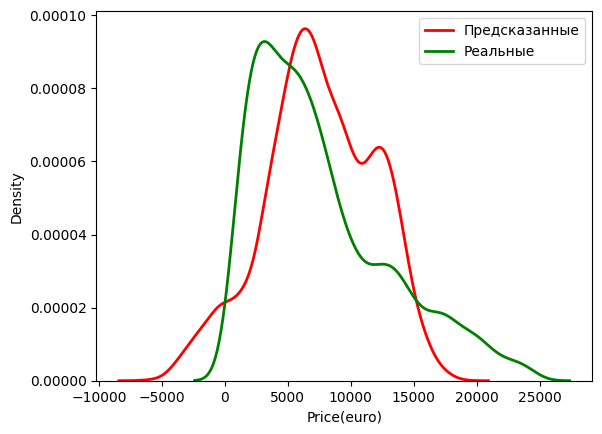

In [886]:
sns.kdeplot(y_pred_ridge, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [887]:
el = ElasticNet(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_el = el.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_el)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_el)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_el))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_el)}')
print(f'R^2: {r2_score(y_test, y_pred_el)}')
el.coef_

MAE: 2351.9708357430663
MSE: 10257913.297828821
RMSE: 3202.7977297713983
MAPE: 0.5175480879687826
R^2: 0.64558331561329


array([  -49.0017497 ,   163.38254408,  2417.91812043,  -134.03843745,
        -538.62278517,  1163.08436763,  -156.90510727, -1224.9587144 ])

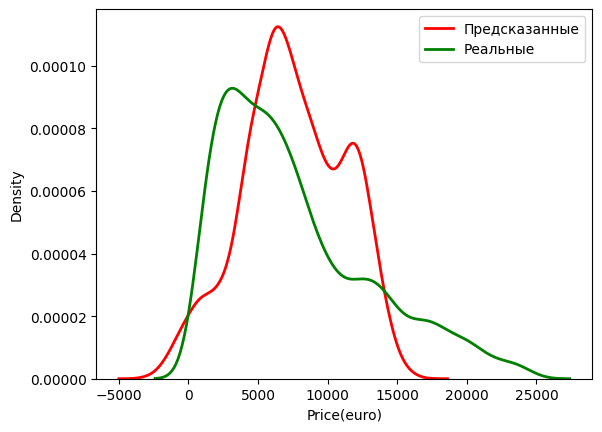

In [888]:
sns.kdeplot(y_pred_el, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [889]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)
lr2 = LinearRegression().fit(X_train_p, y_train)
y_pred_p = lr2.predict(X_test_p)
print(f'MAE: {mean_absolute_error(y_test, y_pred_p)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_p)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_p))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_p)}')
print(f'R^2: {r2_score(y_test, y_pred_p)}')
lr2.coef_

MAE: 1737.1932121646223
MSE: 6058418.851115214
RMSE: 2461.3855551528723
MAPE: 0.38170911890258613
R^2: 0.7906782150037601


array([ 102.21433447,   37.4951947 , 4539.66868481, -175.33322272,
        131.12432232, 1664.13790256, -137.65983636, -540.57515541,
         63.39141538,  149.10997312,  -41.09127577,   88.35742317,
         41.74589802, -214.94489744,    8.02421791,  245.01162698,
         93.92481686,   88.12333798,  -70.7773636 ,  -54.57074049,
        117.1482964 ,  -47.96818921,    5.78561557, 1047.65713471,
       -122.27141282,  -14.77605453,  806.16980207, -164.66702214,
       -574.65178963,   -8.66016445,   26.38476086,  -31.17365523,
         47.12745745,   38.19318747,  -60.15191058,    6.81858811,
        -31.50988802,  -64.16496497,  -39.83571989, -220.73896647,
       -156.57996644,  483.68279171,   43.1360226 ,  237.23056325])

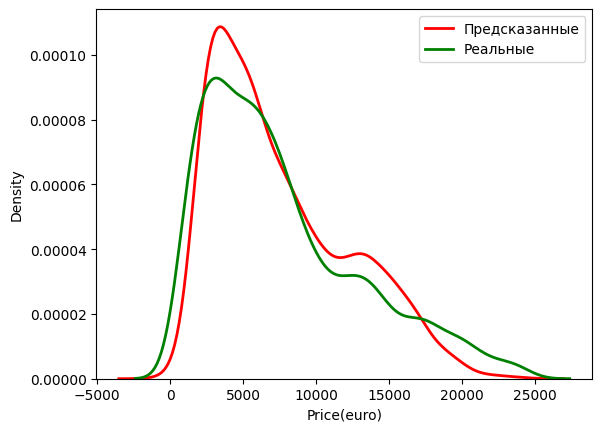

In [890]:
sns.kdeplot(y_pred_p, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

# Поиск оптимального гиперпараметра для моделей 

In [891]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [892]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1)}

In [893]:
lasso_optimal = GridSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели Lasso методом GridSearchCV: {lasso_optimal.best_params_}")
lasso_optimal = RandomizedSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели Lasso методом RandomizedSearchCV: {lasso_optimal.best_params_}")

ridge_optimal = GridSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"\nЛучший параметр для модели Ridge методом GridSearchCV: {ridge_optimal.best_params_}")
ridge_optimal = RandomizedSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели Ridge методом RandomizedSearchCV: {ridge_optimal.best_params_}")

parameters = {'alpha': np.arange(0.1, 10.1, 0.1), 'l1_ratio': np.arange(0.1, 1.1, 0.1)}
el_optimal = GridSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"\nЛучший параметр для модели ElasticNet методом GridSearchCV: {el_optimal.best_params_}")
el_optimal = RandomizedSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели ElasticNet методом RandomizedSearchCV: {el_optimal.best_params_}")

Лучший параметр для модели Lasso методом GridSearchCV: {'alpha': np.float64(0.5)}
Лучший параметр для модели Lasso методом RandomizedSearchCV: {'alpha': np.float64(0.8)}

Лучший параметр для модели Ridge методом GridSearchCV: {'alpha': np.float64(10.0)}
Лучший параметр для модели Ridge методом RandomizedSearchCV: {'alpha': np.float64(9.700000000000001)}

Лучший параметр для модели ElasticNet методом GridSearchCV: {'alpha': np.float64(0.5), 'l1_ratio': np.float64(1.0)}
Лучший параметр для модели ElasticNet методом RandomizedSearchCV: {'l1_ratio': np.float64(0.9), 'alpha': np.float64(3.1)}


In [894]:
import optuna as pt

def optuna(model_name, X_train, y_train, X_test, y_test):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 1e2)

        if model_name == 'lasso':
            model = Lasso(alpha=alpha)
        elif model_name == 'ridge':
            model = Ridge(alpha=alpha)
        elif model_name == 'elasticnet':
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return mse
    
    # Настраиваем оптимизацию гиперпараметров
    study = pt.create_study(direction='minimize')
    study.optimize(objective, n_trials=100)

    # Выводим лучшие гиперпараметры
    best_params = study.best_params
    
    return best_params['alpha'] if model_name != 'elasticnet' else (best_params['alpha'], best_params['l1_ratio'])


In [895]:
models = ('lasso', 'ridge', 'elasticnet')
best_params = {}

for model in models:
    best_param = optuna(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    best_params[f'{model}_optuna'] = best_param

[I 2025-09-23 19:34:18,371] A new study created in memory with name: no-name-a7031217-c22e-4e8d-bcb4-60b777ee6a57
[I 2025-09-23 19:34:18,387] Trial 0 finished with value: 9609477.862959763 and parameters: {'alpha': 69.02855073847597}. Best is trial 0 with value: 9609477.862959763.
[I 2025-09-23 19:34:18,397] Trial 1 finished with value: 9594808.521495538 and parameters: {'alpha': 46.03627394905828}. Best is trial 1 with value: 9594808.521495538.
[I 2025-09-23 19:34:18,404] Trial 2 finished with value: 9608813.380002242 and parameters: {'alpha': 68.12936310197612}. Best is trial 1 with value: 9594808.521495538.
[I 2025-09-23 19:34:18,412] Trial 3 finished with value: 9579200.463140504 and parameters: {'alpha': 19.294567673222378}. Best is trial 3 with value: 9579200.463140504.
[I 2025-09-23 19:34:18,432] Trial 4 finished with value: 9633650.617847724 and parameters: {'alpha': 96.85656152335451}. Best is trial 3 with value: 9579200.463140504.
[I 2025-09-23 19:34:18,439] Trial 5 finished 

In [896]:
for model in models:
    print(f"Лучший параметр для {model}: {best_params[f'{model}_optuna']}")

Лучший параметр для lasso: 0.022299365775306557
Лучший параметр для ridge: 0.02719432173816322
Лучший параметр для elasticnet: (0.0007897479839051869, 0.9732235526705092)


# Построение pipelines


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 2)
MAE: 1737.1932121646228
MSE: 6058418.851115219
RMSE: 2461.3855551528736
MAPE: 0.3817091189025837
R^2: 0.7906782150037599


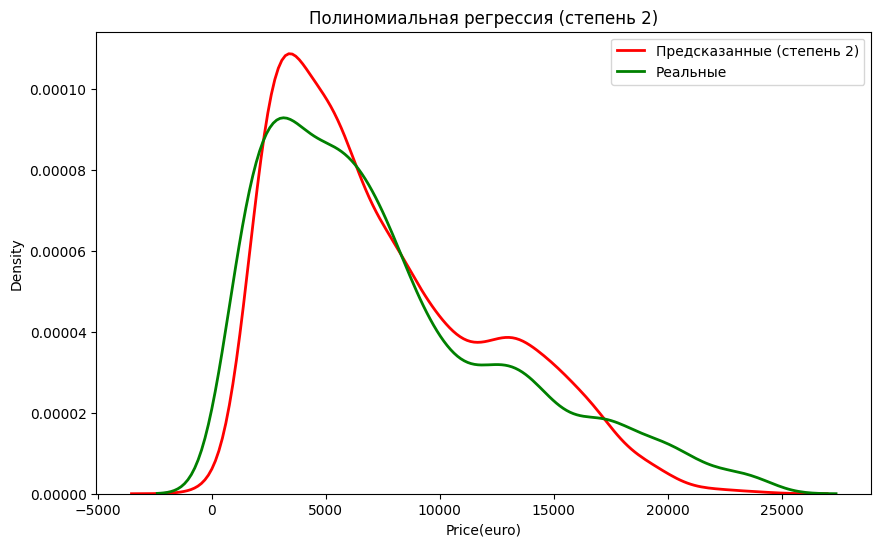


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 3)
MAE: 1650.908207614806
MSE: 5578399.4596210625
RMSE: 2361.863556520796
MAPE: 0.35027321784611404
R^2: 0.8072631554526808


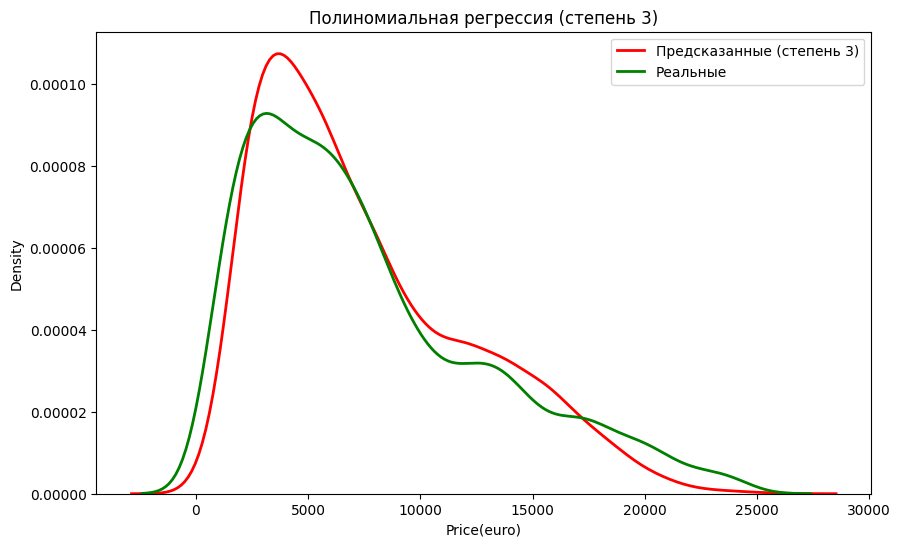


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 4)
MAE: 1532.3664151555436
MSE: 4987583.029978192
RMSE: 2233.2897326540933
MAPE: 0.34282179630074777
R^2: 0.8276761959995862


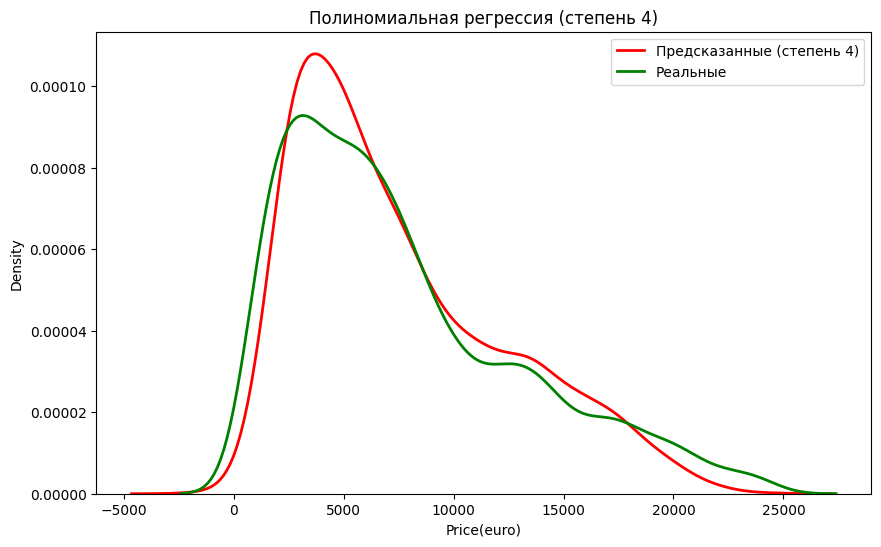

In [897]:
# Создание и использование пайплайна для полиномиальной регрессии
from sklearn.pipeline import Pipeline

# Тестирование полиномиальной регрессии с разными степенями
degrees = [2, 3, 4]  # Можно добавить и другие степени

for degree in degrees:
    print(f"\n{'='*50}")
    print(f"ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень {degree})")
    print(f"{'='*50}")
    
    # Создание пайплайна для текущей степени
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear_reg', LinearRegression())
    ])
    
    # Обучение и предсказание
    poly_pipeline.fit(X_train, y_train)
    y_pred_poly = poly_pipeline.predict(X_test)
    
    # Оценка качества
    print(f'MAE: {mean_absolute_error(y_test, y_pred_poly)}')
    print(f'MSE: {mean_squared_error(y_test, y_pred_poly)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_poly))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_poly)}')
    print(f'R^2: {r2_score(y_test, y_pred_poly)}')
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_pred_poly, color='red', label=f'Предсказанные (степень {degree})', linewidth=2)
    sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
    plt.title(f'Полиномиальная регрессия (степень {degree})')
    plt.legend()
    plt.show()